In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [20]:
def f(t,A,B,tau):
    return A + B * np.exp(-t/tau)

def f_new(t,A,g,tau):
    return g * (1 + A*np.exp(-t/tau))

TransferFunctionContinuous(
array([3.37685000e-01, 1.05658388e+05]),
array([1.00000000e+00, 2.81092325e+05]),
dt: None
)
7200


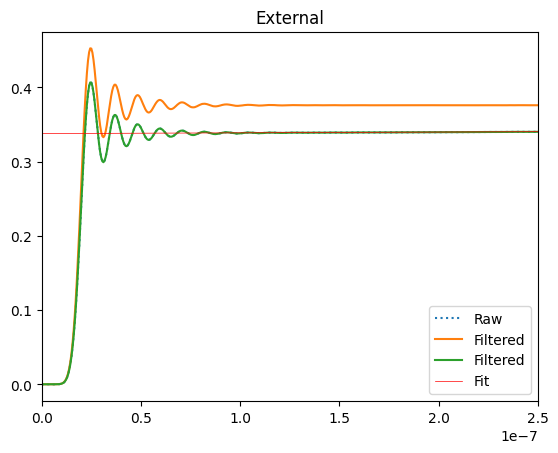

In [122]:

A = 375.885*1e-3 # mV
B = -38.2*1e-3 # mV
tau = 3557.55e-9 # ns

fs = 1.8e9 #Hz
Ts = 1/fs
#System Filter is just 1/Inverse

t = np.arange(0,4000e-9, Ts)

system_filter = sp.signal.lti([tau*(A+B), A],[tau,1])
print(system_filter)
print(len(t))

t,y = sp.signal.step(system_filter,T=t)
# Design IIR filter (for generating ripples and overshoots)
iir_b, iir_a = sp.signal.butter(16, 0.1)
output_iir = sp.signal.lfilter(iir_b, iir_a, y)

output_iir +=  + 0.2e-4 * np.random.normal(0,1, len(t))
# Design IIR filter (for generating ripples and overshoots)
# iir_b, iir_a = sp.signal.butter(16, 0.1)
# y = sp.signal.lfilter(iir_b, iir_a, y)
plt.plot(t, output_iir, ":",label='Raw')

start=500
stop=-1

fit_params, _ = sp.optimize.curve_fit(f_new,t[start:stop], y[start:stop],p0=(100e-3,100e-3,100e-9))

# FROM : https://github.com/DiCarloLab-Delft/PycQED_py3/blob/c4279cbebd97748dc47127e56f6225021f169257/pycqed/measurement/kernel_functions_ZI.py#L21
def exponential_decay_correction(ysig, tau: float, amp: float,
                                 sampling_rate: float=1,
                                 inverse: bool=False):
    """
    Corrects for an exponential decay using a linear IIR filter.

    Fitting should be done to the following function:
        y = gc*(1 + amp *exp(-t/tau))
    where gc is a gain correction factor that is ignored in the corrections.
    """

    # alpha ~1/8 is like averaging 8 samples, sets the timescale for averaging
    # larger alphas break the approximation of the low pass filter
    # numerical instability occurs if alpha > .03
    alpha = 1 - np.exp(-1/(sampling_rate*tau*(1+amp)))
    # the coefficient k (and the filter transfer function)
    # depend on the sign of amp

    if amp >= 0.0:
        k = amp/(1+amp-alpha)
        # compensating overshoot by a low-pass filter
        # correction filter y[n] = (1-k)*x[n] + k*u[n] = x[n] + k*(u[n]-x[n])
        # where u[n] = u[n-1] + alpha*(x[n] - u[n-1])
        a = [(1-k + k*alpha), -(1-k)*(1-alpha)]
    else:
        k = -amp/(1+amp)/(1-alpha)
        # compensating low-pass by an overshoot
        # correction filter y[n] = (1+k)*x[n] - k*u[n] = x[n] - k*(u[n]-x[n])
        # where u[n] = u[n-1] + alpha*(x[n] - u[n-1])
        a = [(1 + k - k*alpha), -(1+k)*(1-alpha)]

    # while the denominator stays the same
    b = [1, -(1-alpha)]
    # if alpha > 0.03 the filter can be unstable.

    if inverse:
        filtered_signal = sp.signal.lfilter(b, a, ysig)
    else:
        filtered_signal = sp.signal.lfilter(a, b, ysig)
    return filtered_signal

A,B,tau = fit_params

y_filtered = exponential_decay_correction(output_iir, tau=tau, amp=A, sampling_rate=fs)

plt.title("External")
plt.plot(t, y_filtered, label='Filtered')
plt.plot(t, output_iir, label='Filtered')
plt.plot(t,f_new(t,A,B,tau), label='Fit', c='r', linewidth=0.5)
plt.legend(loc='best')
plt.xlim(0,250e-9)
plt.show()


In [103]:
import numpy as np
import matplotlib.pyplot as plt

# Function to construct the resampling matrix
def construct_resampling_matrix(N_awg, N_oscilloscope):
    H_res = np.zeros((N_oscilloscope, N_awg))
    
    # Calculate the interpolation factor
    factor = N_awg / N_oscilloscope
    
    for i in range(N_oscilloscope):
        # Determine the indices in the input signal for interpolation
        idx_low = int(np.floor(i * factor))
        idx_high = min(idx_low + 1, N_awg - 1)
        
        # Linear interpolation weights
        weight_high = i * factor - idx_low
        weight_low = 1 - weight_high
        
        # Fill in the resampling matrix
        H_res[i, idx_low] = weight_low
        H_res[i, idx_high] = weight_high
    
    return H_res

# # Generate a sinusoidal signal sampled at a higher rate (simulating AWG rate)
# N_awg = 1000  # Number of samples at AWG rate
# t_awg = np.linspace(0, 1, N_awg)  # Time vector for AWG signal
# f_signal = 10  # Frequency of the sinusoidal signal
# signal_awg = np.sin(2 * np.pi * f_signal * t_awg)  # Sinusoidal signal at AWG rate

# # Resample the signal to a lower rate (simulating oscilloscope rate)
# N_oscilloscope = 900  # Number of samples at oscilloscope rate
# H_resampling = construct_resampling_matrix(N_awg, N_oscilloscope)
# print(H_resampling.shape)
# signal_oscilloscope = np.matmul(H_resampling, signal_awg)  # Resampled signal at oscilloscope rate

# # Plot the original and resampled signals
# plt.figure(figsize=(10, 6))
# plt.plot(t_awg, signal_awg, label='Original Signal (AWG Rate)')
# plt.plot(np.linspace(0, 1, N_oscilloscope), signal_oscilloscope, label='Resampled Signal (Oscilloscope Rate)')
# plt.xlabel('Time')
# plt.ylabel('Amplitude')
# plt.title('Original and Resampled Signals')
# plt.legend()
# plt.grid(True)
# plt.show()


53 300


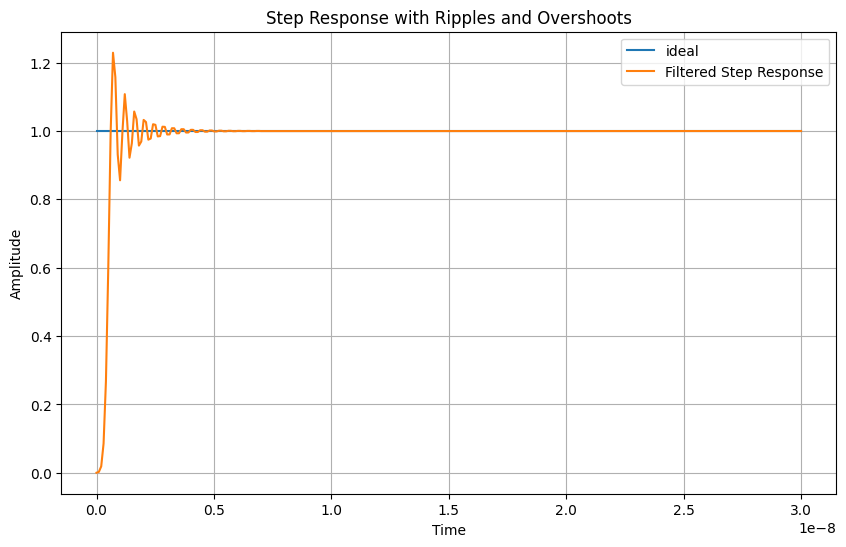

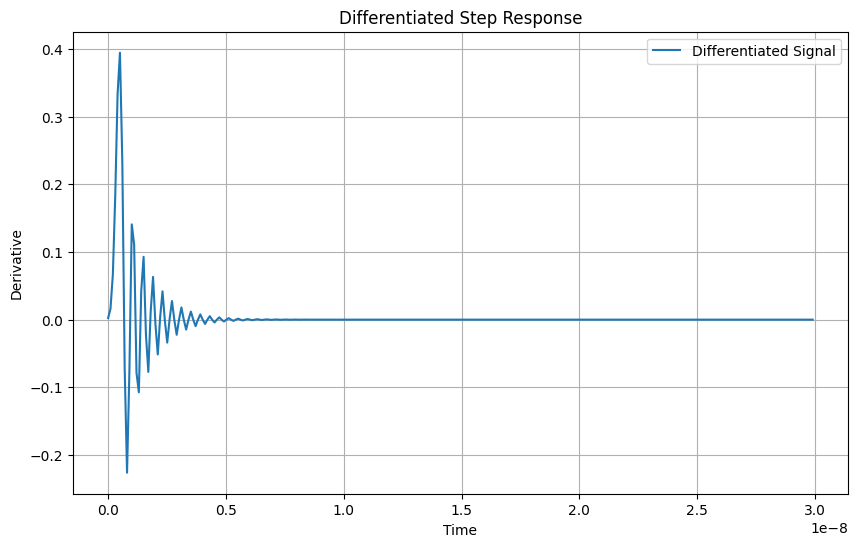

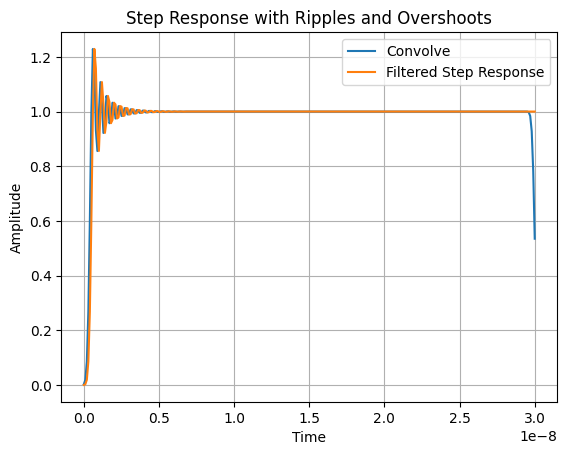

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy as sp

# Define parameters
num_taps_fir = 5  # Number of taps for the FIR filter
num_taps_iir = 15   # Number of taps for the IIR filter

Ts_AWG = 1.8e9
Ts_Osc = 10e9
fs_AWG = 1/Ts_AWG
fs_Osc = 1/Ts_Osc

TPulse = 30e-9

N = int(TPulse * Ts_AWG)

M = int(TPulse * Ts_Osc)

print(N,M)
H_resampling = construct_resampling_matrix(N, M)

D = np.zeros((N-1, N))

# Fill diagonal with 1s
np.fill_diagonal(D, 1)

# Fill above diagonal with -1s
for i in range(N-1):
    D[i, i+1] = -1

# Generate step input
t = np.linspace(0, TPulse, M)
step_input = np.ones_like(t) 
# step_input = sp.ndimage.gaussian_filter1d(step_input, sigma=0.1)


# Design IIR filter (for generating ripples and overshoots)
iir_b, iir_a = signal.butter(num_taps_iir, 0.5)
output_iir = signal.lfilter(iir_b, iir_a, step_input)


# # Design FIR filter (to correct imperfections)
# fir_b = signal.firls(num_taps_fir, [0, 0.1, 0.2, 0.5], [0, 1, 0, 0])
# output_fir = signal.lfilter(fir_b, 1, output_iir)

# Plot the step response
plt.figure(figsize=(10, 6))
plt.plot(t, step_input, label='ideal')
plt.plot(t, output_iir, label='Filtered Step Response')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Step Response with Ripples and Overshoots')
plt.grid(True)
plt.legend()
plt.show()


h = np.diff(output_iir)

# Plot the differentiated signal
plt.figure(figsize=(10, 6))
plt.plot(t[:-1], h, label='Differentiated Signal')
plt.xlabel('Time')
plt.ylabel('Derivative')
plt.title('Differentiated Step Response')
plt.grid(True)
plt.legend()
# plt.xlim(0,50e-9)
plt.show()

Himp = sp.linalg.convolution_matrix(h, n=M)[:M,:M]

# print(M, N,Himp.shape,  H_resampling.shape, x.shape)
# print(Himp.shape, H_resampling.shape)
x = np.ones(N)
y = Himp @ H_resampling @ x
# print(y)

plt.plot(t,y, label='Convolve')
plt.plot(t, output_iir, label='Filtered Step Response')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Step Response with Ripples and Overshoots')
plt.grid(True)
plt.legend()
plt.show()


In [678]:
import torch

y = torch.Tensor(output_iir)

x = torch.zeros(N, requires_grad=True)

# y_ideal = torch.Tensor(step_input)
y_delta = torch.zeros(M)
y_delta[M//2] = 1 
# y_delta[M//2-1:M//2+1] = 1

D = torch.Tensor(D)
Himp_tensor = torch.Tensor(Himp)
Hres_tensor = torch.Tensor(H_resampling)

loss_function = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam([{'params': x, 'lr': 1e-3}])

alpha = 1.

for epoch in range(20000):

    y_pred = torch.mm(
        Himp_tensor,
        torch.mm(
            Hres_tensor, x.unsqueeze(1)
        )
    ).squeeze(1)

    R = torch.pow(
        torch.mm(
            D, x.unsqueeze(1)
        ).squeeze(1), 2
    ).sum()

    loss = loss_function(y_pred, y_delta) + alpha * R
    
    if epoch % 2000 == 0: 
        print(loss)
        
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


tensor(1., grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)
tensor(0.8800, grad_fn=<AddBackward0>)


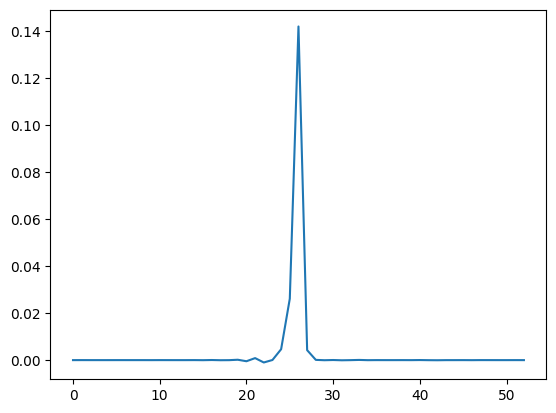

In [679]:
hinv = x.detach().numpy()
plt.plot(hinv)

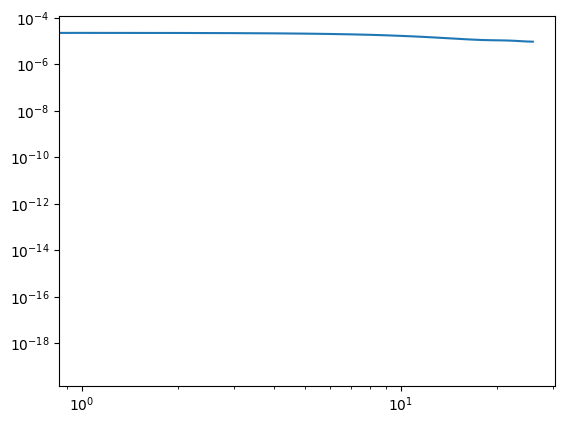

Filter length:  2.9444444444444446e-08


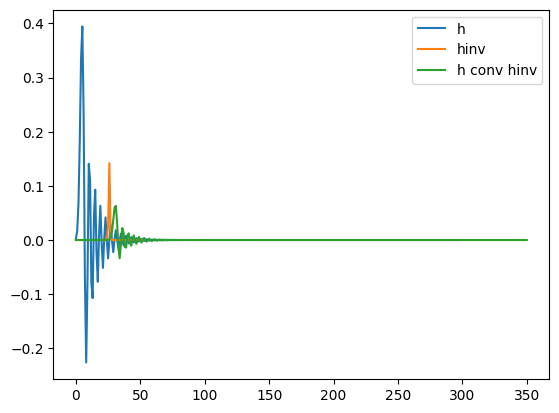

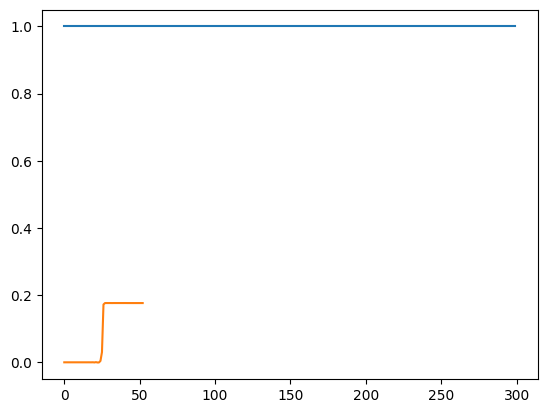

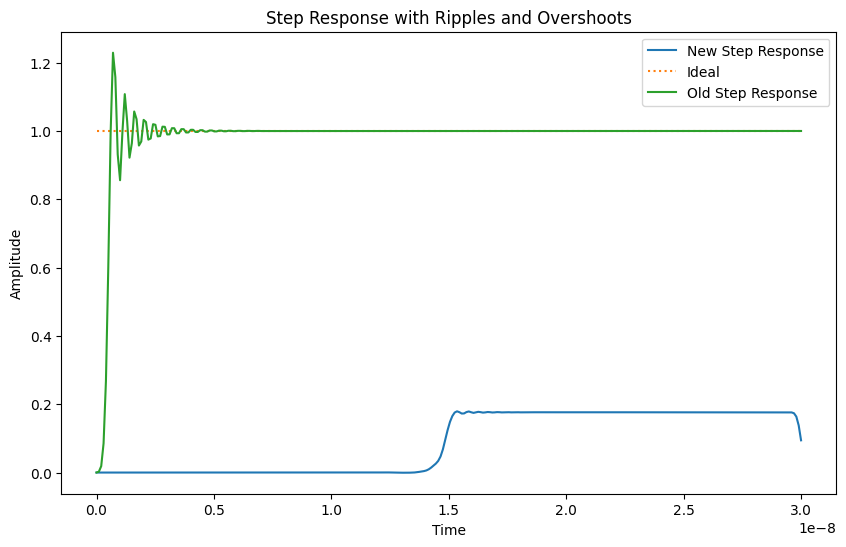

In [680]:

# f, Pxx = sp.signal.periodogram(h, N_awg)
f, Pxx = sp.signal.periodogram(hinv, N, scaling='density')
plt.loglog(
    f, Pxx
)
plt.show()

print("Filter length: ", len(hinv)/(1.8e9))


plt.plot(h, label='h')
plt.plot(hinv, label='hinv')

plt.plot(np.convolve(h,hinv), label='h conv hinv')
plt.legend(loc='best')
plt.show()

test_input = step_input
plt.plot(test_input, label='Ideal Input')
plt.plot(np.convolve(hinv, test_input)[:N], label='Pre-Distorted Input')
filter_x = np.convolve(hinv, test_input)[:N]
new_step_response = Himp @ H_resampling @ filter_x

plt.figure(figsize=(10, 6))
plt.plot(t, new_step_response, label='New Step Response')
plt.plot(t, step_input, ':', label='Ideal')
plt.plot(t, output_iir, label='Old Step Response')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Step Response with Ripples and Overshoots')
# plt.xlim(0,10)
plt.legend()
plt.show()